# Nubzuki Test-Case Analysis

Loads `test_case_*.npy` files and:
1. Visualises the scene interactively (Plotly 3-D)
2. Estimates per-instance statistics (n_pts, anisotropic scales, total scale ratio, density)
3. Plots marginal distributions across all test cases

In [29]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## Constants derived from the native Nubzuki mesh

In [30]:
# Native bounding box of sample.glb (from generation.py constants)
_NATIVE_MIN = np.array([-0.46418998, -0.49921232, -0.40371862], dtype=np.float64)
_NATIVE_MAX = np.array([ 0.4839057,   0.49988693,  0.40684772], dtype=np.float64)
NATIVE_DIMS  = _NATIVE_MAX - _NATIVE_MIN            # [0.948, 0.999, 0.811] m
NATIVE_DIAG  = float(np.linalg.norm(NATIVE_DIMS))   # 1.598 m
NATIVE_GMEAN = float(np.prod(NATIVE_DIMS) ** (1/3)) # geometric mean of dims
NATIVE_SORTED_DIMS = np.sort(NATIVE_DIMS)[::-1]     # [0.999, 0.948, 0.811] m

ASSET_DIR = Path("/home/ubuntu/CS479-Seg/assets/")

print(f"Native dims : {NATIVE_DIMS.round(3)}")
print(f"Native diag : {NATIVE_DIAG:.3f} m")
print(f"Native gmean: {NATIVE_GMEAN:.3f} m")

Native dims : [0.948 0.999 0.811]
Native diag : 1.598 m
Native gmean: 0.916 m


## 1 — Interactive 3-D scene visualisation

Change `FILE_INDEX` (0–4) to switch between test cases.

In [31]:
FILE_INDEX = 0   # ← change this (0–4)

test_paths = sorted(ASSET_DIR.glob("test_case_*.npy"))
print("Available files:")
for i, p in enumerate(test_paths):
    print(f"  [{i}] {p.name}")

Available files:
  [0] test_case_000.npy
  [1] test_case_001.npy
  [2] test_case_002.npy
  [3] test_case_003.npy
  [4] test_case_004.npy


In [32]:
def load_scene(path: Path) -> dict:
    return np.load(path, allow_pickle=True).item()


def visualize_scene(data: dict, title: str = "Scene",
                    bg_subsample: int = 8, obj_subsample: int = 1) -> go.Figure:
    """
    3-D scatter of a scene coloured by instance ID.
    Background (label 0) is shown in grey; each Nubzuki gets a distinct colour.
    """
    xyz    = data["xyz"]
    rgb    = data["rgb"].astype(np.uint8)
    labels = data["instance_labels"]

    instance_ids = sorted(np.unique(labels))
    palette = px.colors.qualitative.Bold   # up to 11 distinct colours

    fig = go.Figure()

    for inst_id in instance_ids:
        mask = labels == inst_id
        pts  = xyz[mask]
        cols = rgb[mask]

        # Sub-sample large clouds for speed
        step = bg_subsample if inst_id == 0 else obj_subsample
        pts  = pts[::step]
        cols = cols[::step]

        if inst_id == 0:
            color_str = [f"rgb({r},{g},{b})" for r, g, b in cols]
            name = f"Background ({mask.sum():,} pts)"
        else:
            hex_col = palette[(inst_id - 1) % len(palette)]
            color_str = hex_col
            name = f"Nubzuki #{inst_id} ({mask.sum():,} pts)"

        fig.add_trace(go.Scatter3d(
            x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
            mode="markers",
            marker=dict(size=1.5, color=color_str, opacity=0.7),
            name=name,
        ))

    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title="X (m)", yaxis_title="Y (m)", zaxis_title="Z (m)",
            aspectmode="data",
        ),
        legend=dict(itemsizing="constant"),
        width=900, height=700,
    )
    return fig


scene_path = test_paths[FILE_INDEX]
scene_data = load_scene(scene_path)
print(f"Loaded {scene_path.name}  —  {len(scene_data['xyz']):,} points total")
print(f"Instance IDs: {np.unique(scene_data['instance_labels'])}")

visualize_scene(scene_data, title=scene_path.stem,
                bg_subsample=6, obj_subsample=1).show()

Loaded test_case_000.npy  —  136,540 points total
Instance IDs: [0 1 2 3 4 5]


## 2 — Per-instance statistics

For each Nubzuki we estimate:

| Quantity | Method |
|---|---|
| **n_pts** | direct count |
| **bbox_x/y/z** | world-space bounding box extent per axis |
| **scale_ratio** | `(∏ bbox_dims)^(1/3) / native_gmean × native_diag / scene_diag` |
| **aniso_1/2/3** | PCA bbox extents sorted descending, divided by `base_scale × sorted native dims` |
| **density** | points / bbox volume |

**Why PCA for aniso scales?**  
The object is rotated arbitrarily, so world-axis bbox dims mix all three original scale axes.
PCA finds the directions of maximum variance of the instance's point cloud — closely aligned with
the original (pre-rotation) scale axes. We then take `max − min` of each projected coordinate
to get the true extent along each PC, and sort both PCA extents and native dims largest-to-smallest
to pair them sensibly regardless of the applied rotation.

In [33]:
def compute_instance_stats(data: dict, scene_path: Path) -> list[dict]:
    xyz    = data["xyz"].astype(np.float64)
    labels = data["instance_labels"]

    scene_diag = float(np.linalg.norm(xyz.max(0) - xyz.min(0)))

    # Background stats
    bg_mask    = labels == 0
    bg_pts     = int(bg_mask.sum())
    bg_bbox    = xyz[bg_mask].max(0) - xyz[bg_mask].min(0)
    bg_vol     = float(np.prod(bg_bbox))
    bg_density = bg_pts / bg_vol

    rows = []
    for inst_id in sorted(np.unique(labels)):
        if inst_id == 0:
            continue

        mask  = labels == inst_id
        pts   = xyz[mask]
        n_pts = int(mask.sum())

        # World-space bounding box
        bbox_dims = pts.max(0) - pts.min(0)           # [bx, by, bz]
        bbox_vol  = float(np.prod(bbox_dims))

        # ── Total scaling (scale_ratio) ─────────────────────────────────────
        # After applying base_scale uniformly + anisotropic sx,sy,sz + random rotation,
        # geometric mean of bbox dims ≈ base_scale × NATIVE_GMEAN × (sx·sy·sz)^(1/3).
        # Anisotropic factors have geometric mean ~1 in expectation, so:
        #   base_scale ≈ gmean(bbox) / NATIVE_GMEAN
        #   scale_ratio = base_scale × NATIVE_DIAG / scene_diag
        gmean_dims   = float(np.prod(bbox_dims) ** (1/3))
        base_scale   = gmean_dims / NATIVE_GMEAN
        scale_ratio  = base_scale * NATIVE_DIAG / scene_diag

        # ── Anisotropic scales via PCA ──────────────────────────────────────
        # Project points onto PCA axes, take full range (max-min) along each.
        # This gives the true extent along each principal direction, avoiding
        # the ~2x underestimate that 2·std produces for non-uniform shapes.
        centered = pts - pts.mean(0)
        cov      = (centered.T @ centered) / len(centered)
        _, eigvecs = np.linalg.eigh(cov)              # ascending eigenvalue order
        eigvecs    = eigvecs[:, ::-1]                 # flip → descending variance
        proj       = centered @ eigvecs               # (N, 3) projections
        pca_extents = proj.max(0) - proj.min(0)       # [e1, e2, e3] descending

        # Pair sorted PCA extents with sorted native dims
        aniso_est = pca_extents / (base_scale * NATIVE_SORTED_DIMS + 1e-9)

        # ── Density ────────────────────────────────────────────────────────
        density = n_pts / (bbox_vol + 1e-12)

        rows.append(dict(
            file          = scene_path.stem,
            inst_id       = int(inst_id),
            scene_diag    = round(scene_diag, 3),
            n_pts         = n_pts,
            bbox_x        = round(float(bbox_dims[0]), 4),
            bbox_y        = round(float(bbox_dims[1]), 4),
            bbox_z        = round(float(bbox_dims[2]), 4),
            scale_ratio   = round(scale_ratio, 4),
            aniso_1       = round(float(aniso_est[0]), 4),
            aniso_2       = round(float(aniso_est[1]), 4),
            aniso_3       = round(float(aniso_est[2]), 4),
            density       = round(density, 2),
            bg_density    = round(bg_density, 2),
            density_ratio = round(density / (bg_density + 1e-12), 4),
            bg_pts        = bg_pts,
            pts_ratio     = round(n_pts / (bg_pts + 1e-12), 6),
        ))

    return rows


all_rows = []
for p in test_paths:
    d = load_scene(p)
    all_rows.extend(compute_instance_stats(d, p))

df = pd.DataFrame(all_rows)
print(f"Total instances across all test cases: {len(df)}")
df

Total instances across all test cases: 21


,file,inst_id,scene_diag,n_pts,bbox_x,bbox_y,bbox_z,scale_ratio,aniso_1,aniso_2,aniso_3,density,bg_density,density_ratio,bg_pts,pts_ratio
0,test_case_000,1,3.874,15823,0.1433,0.1726,0.1776,0.0738,1.0511,1.0115,0.6712,3603534.82,5241.63,687.4835,56749,0.278824
1,test_case_000,2,3.874,18593,0.2976,0.3427,0.3026,0.1413,1.0098,1.0309,0.8499,602297.92,5241.63,114.9066,56749,0.327636
2,test_case_000,3,3.874,12430,0.3396,0.4077,0.4362,0.1767,1.2034,0.9219,0.4239,205859.05,5241.63,39.2739,56749,0.219035
3,test_case_000,4,3.874,16702,0.1118,0.2210,0.1764,0.0736,1.2468,1.0533,0.7886,3831305.04,5241.63,730.9376,56749,0.294314
4,test_case_000,5,3.874,16243,0.1449,0.1426,0.1048,0.0583,1.0189,1.0362,0.8994,7506571.04,5241.63,1432.1060,56749,0.286225
5,test_case_001,1,3.874,25036,0.1633,0.1256,0.0935,0.0560,1.1395,1.1095,0.4477,13052250.02,5241.63,2490.1125,56749,0.441171
6,test_case_001,2,3.874,15831,0.1166,0.1558,0.1511,0.0631,1.0611,1.1572,0.3970,5767506.16,5241.63,1100.3267,56749,0.278965
7,test_case_001,3,3.874,13234,0.0802,0.1052,0.0760,0.0389,1.1079,0.9330,0.9292,20633334.02,5241.63,3936.4341,56749,0.233202
8,test_case_001,4,3.874,2696,0.1712,0.1645,0.1190,0.0674,1.0066,0.9198,0.8982,804506.58,5241.63,153.4840,56749,0.047507
9,test_case_002,1,3.874,19973,0.1947,0.0794,0.1776,0.0631,1.2149,1.1826,0.5936,7274414.21,5241.63,1387.8151,56749,0.351953


## 3 — Distribution plots

All distributions are pooled across every Nubzuki instance in all 5 test cases.

### 3a — Anisotropic axis scales (sx, sy, sz pooled)

Since x, y, z are sampled the same way (`Uniform(0.5, 1.5)`) we pool all three PCA-axis estimates.

In [34]:
aniso_all = pd.concat([
    df["aniso_1"].rename("aniso"),
    df["aniso_2"].rename("aniso"),
    df["aniso_3"].rename("aniso"),
])

fig = go.Figure()
fig.add_trace(go.Histogram(
    x=aniso_all, nbinsx=20,
    marker_color="steelblue", opacity=0.8,
    name="observed"
))
fig.add_vline(x=0.5, line_dash="dash", line_color="red",
              annotation_text="min=0.5", annotation_position="top right")
fig.add_vline(x=1.5, line_dash="dash", line_color="red",
              annotation_text="max=1.5", annotation_position="top left")
fig.update_layout(
    title="(a) Anisotropic axis scale distribution (all axes pooled)",
    xaxis_title="Estimated anisotropic scale (sx / sy / sz)",
    yaxis_title="Count",
    bargap=0.05, width=750, height=400,
)
fig.show()

print(f"Mean: {aniso_all.mean():.3f}   Std: {aniso_all.std():.3f}")
print(f"Min : {aniso_all.min():.3f}   Max : {aniso_all.max():.3f}")
print(f"Expected range: [0.5, 1.5]")

Mean: 0.951   Std: 0.228
Min : 0.359   Max : 1.410
Expected range: [0.5, 1.5]


### 3 — Total scale ratio and how it was also distributed

In [35]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=df["scale_ratio"], nbinsx=15,
    marker_color="mediumseagreen", opacity=0.8,
))
fig.add_vline(x=0.025, line_dash="dash", line_color="red",
              annotation_text="min=0.025")
fig.add_vline(x=0.200, line_dash="dash", line_color="red",
              annotation_text="max=0.200")
fig.update_layout(
    title="Total scale ratio (scale_ratio = base_scale × native_diag / scene_diag)",
    xaxis_title="Estimated scale_ratio",
    yaxis_title="Count",
    bargap=0.05, width=750, height=400,
)
fig.show()

print(df[["scale_ratio"]].describe().round(4))

       scale_ratio
count      21.0000
mean        0.0845
std         0.0442
min         0.0365
25%         0.0560
50%         0.0674
75%         0.1008
max         0.1857


### 3b — Nubzuki point density (pts / bbox volume)

In [36]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=df["density"], nbinsx=15,
    marker_color="coral", opacity=0.8,
))
fig.update_layout(
    title="(b) Nubzuki density  (points / bounding-box volume  [pts/m³])",
    xaxis_title="Density  (pts / m³)",
    yaxis_title="Count",
    bargap=0.05, width=750, height=400,
)
fig.show()

print(df[["density", "bg_density"]].describe().round(1))

          density  bg_density
count        21.0        21.0
mean    4764577.0      4459.0
std     5624069.5      1022.3
min      169686.9      3187.2
25%      804506.6      3187.2
50%     2725756.5      5241.6
75%     7274414.2      5241.6
max    20633334.0      5241.6


### 3c — Density ratio (Nubzuki / background)

In [37]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=df["density_ratio"], nbinsx=15,
    marker_color="mediumpurple", opacity=0.8,
))
fig.add_vline(x=1.0, line_dash="dot", line_color="black",
              annotation_text="equal density")
fig.update_layout(
    title="(c) Density ratio  (Nubzuki density / background density)",
    xaxis_title="Density ratio",
    yaxis_title="Count",
    bargap=0.05, width=750, height=400,
)
fig.show()

print(df[["density_ratio"]].describe().round(2))

       density_ratio
count          21.00
mean         1095.08
std          1336.23
min            39.27
25%           173.29
50%           520.02
75%          1387.82
max          4903.83


### 3d — Number of points sampled per Nubzuki

In [38]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=df["n_pts"], nbinsx=15,
    marker_color="darkorange", opacity=0.8,
))
fig.update_layout(
    title="(d) Points sampled per Nubzuki instance",
    xaxis_title="n_pts",
    yaxis_title="Count",
    bargap=0.05, width=750, height=400,
)
fig.show()

print(df[["n_pts"]].describe().round(0).astype(int))

       n_pts
count     21
mean   14733
std     6898
min     2557
25%     9926
50%    15831
75%    18681
max    26924


### 3e — Ratio of Nubzuki points to background points

In [39]:
fig = go.Figure()
fig.add_trace(go.Histogram(
    x=df["pts_ratio"] * 100, nbinsx=15,
    marker_color="teal", opacity=0.8,
))
fig.update_layout(
    title="(e) Nubzuki points as % of background points",
    xaxis_title="n_pts_nubzuki / n_pts_background  (%)",
    yaxis_title="Count",
    bargap=0.05, width=750, height=400,
)
fig.show()

print((df["pts_ratio"] * 100).describe().round(2).rename("pts_ratio (%)"))

count    21.00
mean     25.71
std      12.03
min       4.39
25%      17.05
50%      27.88
75%      32.76
max      46.24
Name: pts_ratio (%), dtype: float64


### 3f — Point count vs instance size

**Goal:** determine whether `n_pts` (Nubzuki point count) scales with relative instance size, and if so, recover the sampling formula.

Three plots:
- **(f-1)** `pts_ratio` vs `rel_size = nubzuki_bbox_diag / scene_diag` — correlation and linear fit
- **(f-2)** Log–log scatter of `n_pts` vs `base_scale` — power law fit (slope 2 = surface area, 3 = volume)
- **(f-3)** Hypothesis comparison table (H1–H5)

In [40]:
# ── 3f-1  pts_ratio vs relative instance size ─────────────────────────────────
from scipy import stats as sp_stats

df["nubzuki_diag"] = np.sqrt(df["bbox_x"]**2 + df["bbox_y"]**2 + df["bbox_z"]**2)
df["rel_size"]     = df["nubzuki_diag"] / df["scene_diag"]

r_val, p_val = sp_stats.pearsonr(df["rel_size"], df["pts_ratio"])

scene_colors = {
    "test_case_000": "cornflowerblue",
    "test_case_001": "salmon",
    "test_case_002": "mediumseagreen",
    "test_case_003": "gold",
    "test_case_004": "mediumpurple",
}

fig = go.Figure()
for scene, grp in df.groupby("file"):
    fig.add_trace(go.Scatter(
        x=grp["rel_size"],
        y=grp["pts_ratio"] * 100,
        mode="markers+text",
        marker=dict(size=12, color=scene_colors.get(scene, "grey")),
        text=grp["inst_id"].astype(str),
        textposition="top center",
        textfont=dict(size=9),
        name=scene,
        hovertext=[
            f"<b>{scene} #{int(r.inst_id)}</b><br>"
            f"rel_size = {r.rel_size:.4f}<br>"
            f"pts_ratio = {r.pts_ratio*100:.1f}%<br>"
            f"n_pts = {r.n_pts:,}  |  bg_pts = {r.bg_pts:,}<br>"
            f"scale_ratio = {r.scale_ratio:.4f}"
            for _, r in grp.iterrows()
        ],
        hoverinfo="text",
    ))

x_line = np.linspace(df["rel_size"].min(), df["rel_size"].max(), 60)
z = np.polyfit(df["rel_size"], df["pts_ratio"] * 100, 1)
fig.add_trace(go.Scatter(
    x=x_line, y=np.poly1d(z)(x_line),
    mode="lines",
    line=dict(dash="dot", color="white", width=1.5),
    name=f"Linear fit  r={r_val:.3f}  p={p_val:.3f}",
))

fig.update_layout(
    title=(f"(f-1)  Nubzuki / background point ratio  vs  relative instance size<br>"
           f"<sub>Pearson r = {r_val:.3f}  (p = {p_val:.4f})  |  "
           f"rel_size = nubzuki_bbox_diagonal / scene_diagonal</sub>"),
    xaxis_title="Relative size  (nubzuki_diag / scene_diag)",
    yaxis_title="pts_ratio  [%]  (n_nubzuki / n_bg × 100)",
    width=860, height=500,
)
fig.show()

print(f"Pearson r(rel_size, pts_ratio) = {r_val:.4f}  (p = {p_val:.4f})")
print(f"\nCorrelation matrix:")
print(df[["n_pts", "pts_ratio", "rel_size", "scale_ratio"]].corr().round(3).to_string())

Pearson r(rel_size, pts_ratio) = 0.2964  (p = 0.1919)

Correlation matrix:
             n_pts  pts_ratio  rel_size  scale_ratio
n_pts        1.000      1.000     0.295        0.260
pts_ratio    1.000      1.000     0.296        0.262
rel_size     0.295      0.296     1.000        0.996
scale_ratio  0.260      0.262     0.996        1.000


In [41]:
# ── 3f-2  Log-log: n_pts vs base_scale — power law fit ───────────────────────
from scipy import stats as sp_stats

df["base_scale"]    = df["scale_ratio"] * df["scene_diag"] / NATIVE_DIAG
df["n_pts_formula"] = np.clip(104_000 * df["base_scale"]**2, 500, 40_000)

log_bs = np.log(df["base_scale"])
log_np = np.log(df["n_pts"])
slope_ll, intercept_ll, r_ll, p_ll, _ = sp_stats.linregress(log_bs, log_np)

bs_curve  = np.linspace(df["base_scale"].min() * 0.9, df["base_scale"].max() * 1.1, 120)
n_formula = np.clip(104_000 * bs_curve**2, 500, 40_000)
n_fitted  = np.exp(intercept_ll) * bs_curve**slope_ll

fig = go.Figure()
for scene, grp in df.groupby("file"):
    fig.add_trace(go.Scatter(
        x=grp["base_scale"], y=grp["n_pts"],
        mode="markers",
        marker=dict(size=12, color=scene_colors.get(scene, "grey")),
        name=scene,
        hovertext=[
            f"<b>{scene} #{int(r.inst_id)}</b><br>"
            f"base_scale = {r.base_scale:.4f}<br>"
            f"n_pts = {r.n_pts:,}<br>"
            f"formula = {int(np.clip(104_000*r.base_scale**2, 500, 40_000)):,}"
            for _, r in grp.iterrows()
        ],
        hoverinfo="text",
    ))

fig.add_trace(go.Scatter(
    x=bs_curve, y=n_formula,
    mode="lines", line=dict(color="red", dash="dash"),
    name="clip(104 000 × base_scale², 500, 40 000)",
))
fig.add_trace(go.Scatter(
    x=bs_curve, y=n_fitted,
    mode="lines", line=dict(color="yellow", dash="dot"),
    name=f"OLS: {np.exp(intercept_ll):.0f}·bs^{slope_ll:.2f}  (R²={r_ll**2:.3f})",
))

fig.update_layout(
    title=(f"(f-2)  n_pts vs base_scale  (log–log)  —  slope = {slope_ll:.2f}<br>"
           f"<sub>slope ≈ 2 → surface-area sampling  |  slope ≈ 3 → volume sampling</sub>"),
    xaxis_title="base_scale  (gmean(bbox_dims) / NATIVE_GMEAN)",
    yaxis_title="n_pts",
    xaxis_type="log", yaxis_type="log",
    width=860, height=500,
)
fig.show()

ratio = df["n_pts"] / df["n_pts_formula"]
print(f"OLS power law:  n_pts ≈ {np.exp(intercept_ll):.0f} × base_scale^{slope_ll:.3f}")
print(f"R² (log-log) = {r_ll**2:.4f}   p = {p_ll:.6f}")
print(f"\nActual / formula:  mean={ratio.mean():.3f}  std={ratio.std():.3f}  "
      f"min={ratio.min():.3f}  max={ratio.max():.3f}")

OLS power law:  n_pts ≈ 20819 × base_scale^0.310
R² (log-log) = 0.0483   p = 0.338584

Actual / formula:  mean=4.900  std=4.347  min=0.494  max=14.311


In [42]:
# ── 3f-3  Hypothesis comparison ───────────────────────────────────────────────
from scipy import stats as sp_stats

ss_tot = ((df["n_pts"] - df["n_pts"].mean())**2).sum()

cv_npts  = df["n_pts"].std() / df["n_pts"].mean()
cv_ratio = df["pts_ratio"].std() / df["pts_ratio"].mean()

c3   = float(np.exp(np.mean(np.log(df["n_pts"]) - 2 * np.log(df["base_scale"]))))
r2_h3 = 1 - ((df["n_pts"] - c3 * df["base_scale"]**2)**2).sum() / ss_tot

c4   = float(np.exp(np.mean(np.log(df["n_pts"]) - 3 * np.log(df["base_scale"]))))
r2_h4 = 1 - ((df["n_pts"] - c4 * df["base_scale"]**3)**2).sum() / ss_tot

r2_h5 = 1 - ((df["n_pts"] - df["n_pts_formula"])**2).sum() / ss_tot
mae_h5 = (df["n_pts"] - df["n_pts_formula"]).abs().mean()

slope_ll, _, _, _, _ = sp_stats.linregress(np.log(df["base_scale"]), np.log(df["n_pts"]))

print("=" * 65)
print("HYPOTHESIS COMPARISON — point sampling mechanism")
print("=" * 65)
print(f"\nH1: n_pts = constant")
print(f"    CoV(n_pts)     = {cv_npts:.3f}   [0 → constant, high → size-dependent]")
print(f"\nH2: n_pts ∝ bg_pts  (pts_ratio constant)")
print(f"    CoV(pts_ratio) = {cv_ratio:.3f}   [0 → proportional to bg]")
print(f"\nH3: n_pts = {c3:.0f} × base_scale²  (surface-area, free C)")
print(f"    R² = {r2_h3:.4f}")
print(f"\nH4: n_pts = {c4:.0f} × base_scale³  (volume, free C)")
print(f"    R² = {r2_h4:.4f}")
print(f"\nH5: clip(104 000 × base_scale², 500, 40 000)  [stated formula]")
print(f"    R² = {r2_h5:.4f}   MAE = {mae_h5:.0f} pts")
print(f"    Instances at ceiling (theory ≥ 40k): {(df['n_pts_formula'] >= 39_999).sum()}")
print(f"    Instances at floor   (theory ≤ 501):  {(df['n_pts_formula'] <= 501).sum()}")
print(f"\nLog-log OLS slope = {slope_ll:.2f}  (2 = surface-area, 3 = volume)")
print(f"\n{'='*65}")
print("RANKING by R²:")
for lbl, r2 in sorted([("H3 C·bs²", r2_h3), ("H4 C·bs³", r2_h4), ("H5 clip(104k·bs²)", r2_h5)],
                       key=lambda x: x[1], reverse=True):
    print(f"  {lbl:<24}  R² = {r2:.4f}")

HYPOTHESIS COMPARISON — point sampling mechanism

H1: n_pts = constant
    CoV(n_pts)     = 0.468   [0 → constant, high → size-dependent]

H2: n_pts ∝ bg_pts  (pts_ratio constant)
    CoV(pts_ratio) = 0.468   [0 → proportional to bg]

H3: n_pts = 327608 × base_scale²  (surface-area, free C)
    R² = -7.8347

H4: n_pts = 1674078 × base_scale³  (volume, free C)
    R² = -52.3424

H5: clip(104 000 × base_scale², 500, 40 000)  [stated formula]
    R² = -1.9713   MAE = 9890 pts
    Instances at ceiling (theory ≥ 40k): 0
    Instances at floor   (theory ≤ 501):  0

Log-log OLS slope = 0.31  (2 = surface-area, 3 = volume)

RANKING by R²:
  H5 clip(104k·bs²)         R² = -1.9713
  H3 C·bs²                  R² = -7.8347
  H4 C·bs³                  R² = -52.3424


### 3f — Point count vs instance size: findings and hypotheses

**Finding (f-1):** `pts_ratio` has only a weak, non-significant positive correlation with `rel_size`
(Pearson r ≈ 0.30, p ≈ 0.19). The point budget is not clearly driven by object size.

**Finding (f-2):** The log–log slope of `n_pts` vs `base_scale` is ≈ **0.31**, far below 2 (surface
area) or 3 (volume). The quadratic formula `104 000 × base_scale²` has **negative R²** — it fits
worse than predicting the mean, and dramatically underestimates most instances.

#### What the data shows

- Most instances cluster around **10 000–20 000 points** regardless of scale.
- A few outliers (2 557, 2 696, 4 999, 7 495) have far fewer — likely heavily occluded placements.
- CoV(n_pts) ≈ 0.47 is driven mostly by those outliers, not by systematic size scaling.

#### Revised hypotheses for the generation pipeline

| Hypothesis | Description | Consistent? |
|---|---|---|
| **Fixed budget + occlusion** | A large fixed point budget per object; scene occlusion culling reduces final count. Unoccluded → ~20–26k; occluded → 2–5k. | ✓ Explains near-constant mid-range + outliers |
| **Mesh vertex density** | Points sampled at mesh-vertex resolution; at the observed scale range the quadratic factor is swamped by mesh resolution limits. | ✓ Matches clustering |
| **Formula with much larger C** | n_pts ∝ C × base_scale² with C ≈ 700 000–1 000 000 (not 104 000). The scale range here may be too narrow to see the trend clearly. | Possible but R² still low |
| **`104 000 × base_scale²`** | Stated formula. | ✗ Negative R²; underestimates by 5–13× for typical instances |

**Most likely mechanism:** the generation inserts the Nubzuki and retains points surviving scene-level
raycasting or nearest-neighbour matching — a budget driven primarily by object *visibility*, not
geometric size. The `104 000` coefficient may apply at a different normalisation scale, or the true
formula has a much larger pre-clip coefficient with the 40 000 ceiling binding earlier than expected.

## 4 — Summary: scatter of n_pts vs scale_ratio

In [43]:
# Theoretical curve: base_scale = scale_ratio * scene_diag / native_diag
# We use the per-row scene_diag to reconstruct base_scale
df["base_scale"] = df["scale_ratio"] * df["scene_diag"] / NATIVE_DIAG
df["n_pts_theory"] = np.clip(104_000 * df["base_scale"] ** 2, 500, 40_000)

sr = np.linspace(df["scale_ratio"].min(), df["scale_ratio"].max(), 100)
# Use mean scene_diag for the theory curve
mean_scene_diag = df["scene_diag"].mean()
bs_curve = sr * mean_scene_diag / NATIVE_DIAG
n_theory_curve = np.clip(104_000 * bs_curve**2, 500, 40_000)

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=df["scale_ratio"], y=df["n_pts"],
    mode="markers",
    marker=dict(size=10, color=df["inst_id"],
                colorscale="Viridis", showscale=True,
                colorbar=dict(title="inst_id")),
    text=df["file"] + " #" + df["inst_id"].astype(str),
    name="observed",
))
fig.add_trace(go.Scatter(
    x=sr, y=n_theory_curve,
    mode="lines", line=dict(color="red", dash="dash"),
    name=f"theory: 104k·base_scale²  (scene_diag={mean_scene_diag:.2f} m)",
))
fig.update_layout(
    title="n_pts vs scale_ratio  (coloured by instance ID)",
    xaxis_title="scale_ratio",
    yaxis_title="n_pts",
    width=850, height=480,
)
fig.show()

In [44]:
import os
import torch

def process_point_clouds(folder_path):
    diagonals = []
    point_counts = []
    file_names = []

    # Find all .npy files in the specified folder
    file_pattern = os.path.join(folder_path, "*.pth")
    files = glob.glob(file_pattern)

    if not files:
        print(f"No .pth files found in {folder_path}")
        return None, None

    for f in files:
        # Load point cloud (expected shape: [N, 3] or [N, C] where first 3 are XYZ)
        data = torch.load(f, map_location='cpu', weights_only=False)
        points = data['xyz']  # Extract only X, Y, Z coordinates

        # 1. Compute Point Count
        point_counts.append(len(points))

        # 2. Compute Scene Diagonal
        min_coords = np.min(points, axis=0)
        max_coords = np.max(points, axis=0)
        diff = max_coords - min_coords
        diag = np.sqrt(np.sum(diff**2))
        diagonals.append(diag)
        file_names.append(os.path.basename(f))

    return np.array(diagonals), np.array(point_counts), file_names

# --- Main Execution ---
folder_path = "/home/ubuntu/CS479-Seg/assets/multiscan/test"  # Change this to your folder
diagonals, point_counts, file_names = process_point_clouds(folder_path)

if diagonals is not None:
    # Create subplots for Diagonal and Point Count
    fig = make_subplots(rows=1, cols=2, subplot_titles=("Scene Diagonals", "Point Counts"))

    # Add Histogram for Diagonals
    fig.add_trace(
        go.Histogram(x=diagonals, name="Diagonal", marker_color='#636EFA'),
        row=1, col=1
    )

    # Add Histogram for Point Counts
    fig.add_trace(
        go.Histogram(x=point_counts, name="Point Count", marker_color='#EF553B'),
        row=1, col=2
    )

    # Update Layout
    fig.update_layout(
        title_text=f"Scene Statistics (Mean Diagonal: {np.mean(diagonals):.2f})",
        showlegend=False,
        template="plotly_white"
    )

    
    
    fig.update_xaxes(title_text="Diagonal Length", row=1, col=1)
    fig.update_xaxes(title_text="Number of Points", row=1, col=2)
    fig.update_yaxes(title_text="Frequency", row=1, col=1)

    fig.show()

In [45]:
fig = go.Figure()
fig.add_trace(go.Scatter(
        x=diagonals,
        y=point_counts,
        mode='markers',
        text=file_names,  # Hover to see the filename
        marker=dict(
            size=10,
            showscale=True,
            line=dict(width=1, color='DarkSlateGrey')
        )
    ))

# Add a trend line (Optional)
z = np.polyfit(diagonals, point_counts, 1)
p = np.poly1d(z)
fig.add_trace(go.Scatter(
    x=diagonals, 
    y=p(diagonals),
    mode='lines',
    name='Trend Line',
    line=dict(color='red', dash='dot')
))

fig.update_layout(
    title="Correlation: Scene Diagonal vs. Point Count",
    xaxis_title="Scene Diagonal (meters)",
    yaxis_title="Number of Points",
    template="plotly_white",
    hovermode="closest"
)


## 5 — Colour Jitter Analysis

Investigates how the `_color_jitter` transform in `generation.py` shapes the appearance of Nubzuki instances.

**Questions answered:**

| Question | Method |
|---|---|
| **Per-instance or per-point jitter?** | Compare within-instance inter-channel correlations to the native mesh baseline. Uniform (per-instance) jitter is a linear transform and preserves correlations; per-point jitter collapses them toward 0. |
| **Distribution of effective "base colours"?** | Colour swatch grid and 3-D RGB-space scatter of per-instance mean colours across all 21 instances. |
| **Do recovered parameters match the stated model?** | Estimate `(scale, shift)` per channel per instance via moment matching and compare to the stated `Uniform(0.5, 2.0)` / `Uniform(−20, 20)` priors. |

**Jitter model (`generation.py`):**
```python
scale = rng.uniform(0.5, 2.0, size=(1, 3))   # one value per channel, broadcast to ALL points
shift = rng.uniform(-20.0, 20.0, size=(1, 3))
rgb_out = clip(rgb_in * scale + shift, 0, 255)
```
This is a **single affine transform per instance** — not per-point.
Each channel is drawn independently, so the dominant channel determines the perceived hue.


In [46]:

# ── 5-B  Per-instance colour statistics ───────────────────────────────────────
import trimesh

# Load native mesh vertex colours (source ground truth for all jitter estimation)
_scene   = trimesh.load(str(ASSET_DIR / "sample.glb"))
_mesh_obj = list(_scene.geometry.values())[0]
native_vc = _mesh_obj.visual.to_color().vertex_colors[:, :3].astype(np.float32)

native_mean   = native_vc.mean(0)   # (3,)
native_std    = native_vc.std(0)    # (3,)
native_corr_RG = float(np.corrcoef(native_vc[:,0], native_vc[:,1])[0,1])
native_corr_RB = float(np.corrcoef(native_vc[:,0], native_vc[:,2])[0,1])
native_corr_GB = float(np.corrcoef(native_vc[:,1], native_vc[:,2])[0,1])

print(f"Native mesh — {len(native_vc):,} vertices")
print(f"  mean  R={native_mean[0]:.1f}  G={native_mean[1]:.1f}  B={native_mean[2]:.1f}")
print(f"  std   R={native_std[0]:.1f}   G={native_std[1]:.1f}   B={native_std[2]:.1f}")
print(f"  corr  RG={native_corr_RG:.3f}  RB={native_corr_RB:.3f}  GB={native_corr_GB:.3f}")

# Per-instance statistics across all 5 test cases
color_rows = []
instance_rgb_samples = {}   # full RGB arrays, keyed by (test_case_stem, inst_id)

for tc_path in test_paths:
    data    = load_scene(tc_path)
    rgb_u8  = data["rgb"]               # (N,3) uint8
    labels  = data["instance_labels"]

    for inst_id in sorted(np.unique(labels)):
        if inst_id == 0:
            continue
        mask     = labels == inst_id
        rgb_inst = rgb_u8[mask].astype(np.float32)   # (M,3) float32 in [0,255]

        m = rgb_inst.mean(0)
        s = rgb_inst.std(0)

        # Recover jitter parameters via moment matching (before clipping):
        #   std(rgb_out_c)  ≈ scale_c * std(rgb_in_c)
        #   mean(rgb_out_c) ≈ scale_c * mean(rgb_in_c) + shift_c
        est_scale = s / (native_std + 1e-9)
        est_shift = m - est_scale * native_mean

        # Within-instance inter-channel Pearson correlations
        corr_RG = float(np.corrcoef(rgb_inst[:,0], rgb_inst[:,1])[0,1])
        corr_RB = float(np.corrcoef(rgb_inst[:,0], rgb_inst[:,2])[0,1])
        corr_GB = float(np.corrcoef(rgb_inst[:,1], rgb_inst[:,2])[0,1])

        instance_rgb_samples[(tc_path.stem, int(inst_id))] = rgb_inst

        color_rows.append(dict(
            file=tc_path.stem, inst_id=int(inst_id), n_pts=int(mask.sum()),
            mean_R=m[0], mean_G=m[1], mean_B=m[2],
            std_R=s[0],  std_G=s[1],  std_B=s[2],
            est_scale_R=est_scale[0], est_scale_G=est_scale[1], est_scale_B=est_scale[2],
            est_shift_R=est_shift[0], est_shift_G=est_shift[1], est_shift_B=est_shift[2],
            corr_RG=corr_RG, corr_RB=corr_RB, corr_GB=corr_GB,
        ))

cdf = pd.DataFrame(color_rows)
print(f"\nInstances analysed: {len(cdf)}  across {cdf['file'].nunique()} test cases")
display(cdf[["file","inst_id","mean_R","mean_G","mean_B",
             "est_scale_R","est_scale_G","est_scale_B",
             "est_shift_R","est_shift_G","est_shift_B"]].round(2))


Native mesh — 11,829 vertices
  mean  R=62.6  G=84.2  B=108.3
  std   R=45.0   G=57.1   B=60.9
  corr  RG=0.971  RB=0.927  GB=0.983

Instances analysed: 21  across 5 test cases


,file,inst_id,mean_R,mean_G,mean_B,est_scale_R,est_scale_G,est_scale_B,est_shift_R,est_shift_G,est_shift_B
0,test_case_000,1,159.289993,87.849998,116.400002,1.55,0.94,1.08,61.900002,8.880000,-0.750000
1,test_case_000,2,71.540001,94.930000,143.589996,1.08,1.04,1.06,3.840000,7.400000,28.299999
2,test_case_000,3,109.610001,124.930000,158.240005,1.28,1.15,1.15,29.709999,27.980000,34.150002
3,test_case_000,4,68.629997,83.809998,98.559998,0.80,0.74,0.72,18.469999,21.139999,20.440001
4,test_case_000,5,163.699997,122.269997,82.629997,1.54,0.91,0.87,67.110001,45.419998,-11.220000
5,test_case_001,1,114.480003,79.080002,93.050003,1.17,0.76,0.83,41.290001,15.160000,3.560000
6,test_case_001,2,114.750000,88.940002,62.779999,1.17,0.71,0.66,41.700001,29.080000,-8.930000
7,test_case_001,3,164.410004,131.100006,99.199997,1.55,0.97,0.91,67.610001,49.490002,1.170000
8,test_case_001,4,145.270004,115.720001,86.900002,1.44,0.90,0.84,54.970001,39.630001,-3.670000
9,test_case_002,1,78.959999,90.050003,157.839996,1.11,1.04,1.15,9.220000,2.870000,33.230000


In [47]:

# ── 5-C  Colour swatch: mean colour per instance ──────────────────────────────
COLS = 7
sx, sy, colors, hover_texts, labels_txt = [], [], [], [], []

for idx, row in cdf.iterrows():
    r = int(np.clip(row["mean_R"], 0, 255))
    g = int(np.clip(row["mean_G"], 0, 255))
    b = int(np.clip(row["mean_B"], 0, 255))
    sx.append(idx % COLS)
    sy.append(-(idx // COLS))
    colors.append(f"rgb({r},{g},{b})")
    labels_txt.append(f"{row['file'][-3:]}#{int(row['inst_id'])}")
    hover_texts.append(
        f"<b>{row['file']} #{int(row['inst_id'])}</b><br>"
        f"Mean   R={r}  G={g}  B={b}<br>"
        f"Scale  R={row['est_scale_R']:.2f}  G={row['est_scale_G']:.2f}  B={row['est_scale_B']:.2f}<br>"
        f"Shift  R={row['est_shift_R']:.1f}  G={row['est_shift_G']:.1f}  B={row['est_shift_B']:.1f}<br>"
        f"n_pts={int(row['n_pts']):,}"
    )

# Append the native mesh mean as a reference swatch
nr, ng, nb = int(native_mean[0]), int(native_mean[1]), int(native_mean[2])

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=sx, y=sy,
    mode="markers+text",
    marker=dict(size=52, color=colors,
                line=dict(color="rgba(200,200,200,0.3)", width=1)),
    text=labels_txt, textposition="middle center",
    textfont=dict(size=9, color="white"),
    hovertext=hover_texts, hoverinfo="text",
    name="Instances",
))
fig.add_trace(go.Scatter(
    x=[COLS+0.5], y=[0],
    mode="markers+text",
    marker=dict(size=52, color=f"rgb({nr},{ng},{nb})",
                line=dict(color="white", width=2)),
    text=["NATIVE"], textposition="middle center",
    textfont=dict(size=9, color="white"),
    hovertext=f"<b>Native mesh mean (no jitter)</b><br>R={nr}  G={ng}  B={nb}",
    hoverinfo="text", name="Native (no jitter)",
))

fig.update_layout(
    title=("Mean colour per Nubzuki instance — hover for jitter stats<br>"
           "<sub>Rightmost swatch (NATIVE) = un-jittered native mesh mean. "
           "Each channel is scaled independently ∈ [0.5, 2.0], "
           "producing colours spanning warm/cool/neutral tones.</sub>"),
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               range=[-0.8, COLS+1.3]),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    plot_bgcolor="rgb(20,20,20)", paper_bgcolor="rgb(20,20,20)",
    legend=dict(bgcolor="rgb(50,50,50)", font=dict(color="white")),
    width=840, height=290,
)
fig.show()


In [48]:

# ── 5-D  3-D RGB colour-space scatter ─────────────────────────────────────────
# Colour each point by its ACTUAL mean colour.
# Label by which channel carries the highest estimated scale — this determines
# the dominant perceived hue shift away from the native blue-grey.

dom_ch_col = cdf[["est_scale_R","est_scale_G","est_scale_B"]].idxmax(axis=1).map(
    {"est_scale_R": "R-dominant (warm/red)",
     "est_scale_G": "G-dominant (yellow-green)",
     "est_scale_B": "B-dominant (cool/blue)"})

fig = go.Figure()
palette = {"R-dominant (warm/red)": "salmon",
           "G-dominant (yellow-green)": "lightgreen",
           "B-dominant (cool/blue)": "cornflowerblue"}

for label, group in cdf.groupby(dom_ch_col):
    gcolors = [
        f"rgb({int(np.clip(r.mean_R,0,255))},{int(np.clip(r.mean_G,0,255))},{int(np.clip(r.mean_B,0,255))})"
        for _, r in group.iterrows()
    ]
    hover = [
        f"<b>{r.file} #{int(r.inst_id)}</b><br>"
        f"Mean  R={r.mean_R:.0f}  G={r.mean_G:.0f}  B={r.mean_B:.0f}<br>"
        f"Scale R={r.est_scale_R:.2f}  G={r.est_scale_G:.2f}  B={r.est_scale_B:.2f}<br>"
        f"Shift R={r.est_shift_R:.1f}  G={r.est_shift_G:.1f}  B={r.est_shift_B:.1f}"
        for _, r in group.iterrows()
    ]
    fig.add_trace(go.Scatter3d(
        x=group["mean_R"], y=group["mean_G"], z=group["mean_B"],
        mode="markers",
        marker=dict(size=11, color=gcolors, line=dict(color="white", width=0.5)),
        hovertext=hover, hoverinfo="text",
        name=label,
    ))

# Native mesh mean
fig.add_trace(go.Scatter3d(
    x=[native_mean[0]], y=[native_mean[1]], z=[native_mean[2]],
    mode="markers+text",
    marker=dict(size=14, symbol="cross", color="white",
                line=dict(color="black", width=2)),
    text=["Native"], textfont=dict(size=9, color="white"),
    hovertext=(f"Native mesh mean<br>"
               f"R={native_mean[0]:.0f}  G={native_mean[1]:.0f}  B={native_mean[2]:.0f}"),
    hoverinfo="text", name="Native mean (un-jittered)",
))

fig.update_layout(
    title=("Instance mean colours in RGB space — grouped by dominant jitter channel<br>"
           "<sub>✕ = native mesh mean (un-jittered). "
           "Instances spread widely because each channel scale is drawn independently.</sub>"),
    scene=dict(
        xaxis=dict(title="R", range=[0,255]),
        yaxis=dict(title="G", range=[0,255]),
        zaxis=dict(title="B", range=[0,255]),
        bgcolor="rgb(30,30,30)",
    ),
    paper_bgcolor="rgb(20,20,20)",
    legend=dict(bgcolor="rgb(50,50,50)", font=dict(color="white")),
    width=820, height=660,
)
fig.show()

print("Dominant-scale-channel breakdown:")
print(dom_ch_col.value_counts().to_string())
print(f"\nMean estimated scales: R={cdf['est_scale_R'].mean():.3f}  "
      f"G={cdf['est_scale_G'].mean():.3f}  B={cdf['est_scale_B'].mean():.3f}")
print(f"(All should be ~1.25 = mean of Uniform(0.5,2.0) under unbiased estimation)")


Dominant-scale-channel breakdown:
R-dominant (warm/red)     18
B-dominant (cool/blue)     3

Mean estimated scales: R=1.177  G=0.893  B=0.932
(All should be ~1.25 = mean of Uniform(0.5,2.0) under unbiased estimation)


In [49]:

# ── 5-E  Recovered jitter parameter distributions ─────────────────────────────
# Estimated via first-moment matching:
#   std(rgb_out_c)  ≈ |scale_c| * std(rgb_in_c_native)
#   mean(rgb_out_c) ≈ scale_c  * mean(rgb_in_c_native) + shift_c
# Dashed lines mark the stated Uniform range boundaries.

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=["Scale R","Scale G","Scale B","Shift R","Shift G","Shift B"],
    vertical_spacing=0.20, horizontal_spacing=0.10,
)
ch_colors = ["indianred", "mediumseagreen", "cornflowerblue"]

for ci, ch in enumerate("RGB"):
    fig.add_trace(go.Histogram(
        x=cdf[f"est_scale_{ch}"], nbinsx=12,
        marker_color=ch_colors[ci], opacity=0.85, showlegend=False,
    ), row=1, col=ci+1)
    for xv, lbl in [(0.5,"0.5"), (2.0,"2.0")]:
        fig.add_vline(x=xv, line_dash="dash", line_color="white",
                      annotation_text=lbl, annotation_font_color="white",
                      row=1, col=ci+1)

    fig.add_trace(go.Histogram(
        x=cdf[f"est_shift_{ch}"], nbinsx=12,
        marker_color=ch_colors[ci], opacity=0.85, showlegend=False,
    ), row=2, col=ci+1)
    for xv, lbl in [(-20,"−20"), (20,"+20")]:
        fig.add_vline(x=xv, line_dash="dash", line_color="white",
                      annotation_text=lbl, annotation_font_color="white",
                      row=2, col=ci+1)

fig.update_layout(
    title=("Recovered jitter parameters per channel — dashes = Uniform range boundaries<br>"
           "<sub>Row 1: scale ∈ [0.5, 2.0]  |  Row 2: shift ∈ [−20, +20]</sub>"),
    paper_bgcolor="rgb(20,20,20)", plot_bgcolor="rgb(30,30,30)",
    font=dict(color="white"),
    width=900, height=540,
)
fig.update_xaxes(gridcolor="rgb(60,60,60)")
fig.update_yaxes(gridcolor="rgb(60,60,60)", title_text="Count")
fig.show()

print("Recovered scale statistics (stated range [0.5, 2.0]):")
for ch in "RGB":
    v = cdf[f"est_scale_{ch}"]
    print(f"  {ch}: mean={v.mean():.3f}  std={v.std():.3f}  "
          f"min={v.min():.3f}  max={v.max():.3f}")
print("\nRecovered shift statistics (stated range [−20, +20]):")
for ch in "RGB":
    v = cdf[f"est_shift_{ch}"]
    print(f"  {ch}: mean={v.mean():.1f}  std={v.std():.1f}  "
          f"min={v.min():.1f}  max={v.max():.1f}")

# Cross-channel scale correlation — independent draws would give ~0
print("\nCross-channel scale Pearson correlations (independent draws → ~0):")
sc = cdf[["est_scale_R","est_scale_G","est_scale_B"]].corr().round(3)
print(sc.to_string())


Recovered scale statistics (stated range [0.5, 2.0]):
  R: mean=1.177  std=0.219  min=0.801  max=1.555
  G: mean=0.893  std=0.150  min=0.598  max=1.152
  B: mean=0.932  std=0.170  min=0.602  max=1.150

Recovered shift statistics (stated range [−20, +20]):
  R: mean=33.4  std=20.4  min=3.8  max=67.6
  G: mean=19.3  std=14.0  min=2.9  max=49.5
  B: mean=14.7  std=16.5  min=-11.2  max=40.7

Cross-channel scale Pearson correlations (independent draws → ~0):
             est_scale_R  est_scale_G  est_scale_B
est_scale_R        1.000        0.351        0.248
est_scale_G        0.351        1.000        0.896
est_scale_B        0.248        0.896        1.000


In [50]:

# ── 5-F  Uniformity test: within-instance inter-channel correlations ──────────
#
# Uniform jitter applies ONE scale and ONE shift per channel to ALL points of an
# instance:  rgb_out_c(p) = s_c * rgb_in_c(p) + d_c  for all p.
# A linear transform preserves Pearson correlation, so:
#   corr(rgb_out_R, rgb_out_G)  =  corr(rgb_in_R, rgb_in_G)  [native value]
#
# Per-point jitter gives each point its own independent (s_c(p), d_c(p)).
# Random multiplicative noise destroys the correlation structure → values near 0.
#
# Verdict: within-instance correlations matching the native baseline confirm
# per-instance (uniform) jitter.

native_corrs = {"RG": native_corr_RG, "RB": native_corr_RB, "GB": native_corr_GB}
print("Native mesh inter-channel correlations  (= prediction under uniform jitter):")
for pair, val in native_corrs.items():
    print(f"  corr({pair[0]},{pair[1]}) = {val:.4f}")

fig = make_subplots(rows=1, cols=3,
    subplot_titles=["corr(R, G)", "corr(R, B)", "corr(G, B)"],
    horizontal_spacing=0.1)

for ci, (pair, col) in enumerate(zip(["RG","RB","GB"],
                                     ["corr_RG","corr_RB","corr_GB"])):
    fig.add_trace(go.Histogram(
        x=cdf[col], nbinsx=10,
        marker_color="steelblue", opacity=0.85, showlegend=False,
    ), row=1, col=ci+1)
    native_val = native_corrs[pair]
    fig.add_vline(x=native_val, line_dash="dash", line_color="red", line_width=2.5,
                  annotation_text=f"native={native_val:.3f}",
                  annotation_font_color="red",
                  row=1, col=ci+1)

fig.update_layout(
    title=("Within-instance inter-channel correlations (blue) vs native mesh baseline (red dash)<br>"
           "<sub>Uniform-jitter prediction: bars cluster at the red line. "
           "Per-point prediction: bars cluster near 0.</sub>"),
    paper_bgcolor="rgb(20,20,20)", plot_bgcolor="rgb(30,30,30)",
    font=dict(color="white"),
    width=900, height=380,
)
fig.update_xaxes(gridcolor="rgb(60,60,60)")
fig.update_yaxes(gridcolor="rgb(60,60,60)", title_text="Count")
fig.show()

print("\nPer-instance observed correlations:")
print(cdf[["file","inst_id","corr_RG","corr_RB","corr_GB"]].round(3).to_string(index=False))

mean_rg = cdf["corr_RG"].mean()
mean_rb = cdf["corr_RB"].mean()
mean_gb = cdf["corr_GB"].mean()
print(f"\nMean observed : corr(R,G)={mean_rg:.3f}  corr(R,B)={mean_rb:.3f}  corr(G,B)={mean_gb:.3f}")
print(f"Native mesh   : corr(R,G)={native_corr_RG:.3f}  corr(R,B)={native_corr_RB:.3f}  corr(G,B)={native_corr_GB:.3f}")

# Also show a R vs G scatter for three instances spanning the colour range to
# illustrate that the internal correlation structure is preserved under jitter.
sample_keys = list(instance_rgb_samples.keys())[:3]
fig2 = make_subplots(rows=1, cols=3,
    subplot_titles=[f"{k[0][-3:]} #{k[1]}" for k in sample_keys],
    horizontal_spacing=0.08)

for ci, key in enumerate(sample_keys):
    rgb_s = instance_rgb_samples[key]
    # sub-sample for speed
    idx_sub = np.random.default_rng(0).choice(len(rgb_s), min(2000, len(rgb_s)), replace=False)
    r_s = instance_rgb_samples[key][idx_sub, 0]
    g_s = instance_rgb_samples[key][idx_sub, 1]
    fig2.add_trace(go.Scatter(
        x=r_s, y=g_s, mode="markers",
        marker=dict(size=2, opacity=0.4,
                    color=[f"rgb({int(r)},{int(g)},{int(b)})"
                           for r, g, b in instance_rgb_samples[key][idx_sub]]),
        showlegend=False,
    ), row=1, col=ci+1)
    fig2.update_xaxes(title_text="R", range=[0,255], row=1, col=ci+1,
                      gridcolor="rgb(60,60,60)")
    fig2.update_yaxes(title_text="G", range=[0,255], row=1, col=ci+1,
                      gridcolor="rgb(60,60,60)")

fig2.update_layout(
    title="R vs G scatter within individual instances (colours = actual point colour)<br>"
          "<sub>Correlation structure preserved under uniform jitter — pattern is stretched/shifted native mesh texture.</sub>",
    paper_bgcolor="rgb(20,20,20)", plot_bgcolor="rgb(30,30,30)",
    font=dict(color="white"),
    width=900, height=360,
)
fig2.show()


Native mesh inter-channel correlations  (= prediction under uniform jitter):
  corr(R,G) = 0.9711
  corr(R,B) = 0.9275
  corr(G,B) = 0.9833



Per-instance observed correlations:
         file  inst_id  corr_RG  corr_RB  corr_GB
test_case_000        1    0.906    0.972    0.970
test_case_000        2    0.970    0.883    0.958
test_case_000        3    0.992    0.963    0.984
test_case_000        4    0.987    0.966    0.992
test_case_000        5    0.959    0.869    0.955
test_case_001        1    0.967    0.988    0.991
test_case_001        2    0.974    0.915    0.968
test_case_001        3    0.977    0.925    0.974
test_case_001        4    0.979    0.932    0.976
test_case_002        1    0.981    0.865    0.925
test_case_002        2    0.993    0.930    0.933
test_case_002        3    0.996    0.969    0.968
test_case_002        4    0.933    0.980    0.979
test_case_003        1    0.979    0.917    0.968
test_case_003        2    0.948    0.983    0.985
test_case_003        3    0.971    0.884    0.958
test_case_004        1    0.992    0.962    0.984
test_case_004        2    0.991    0.931    0.959
test_case_004

## 6 — HSV Colour Analysis

Investigates the **Nubzuki colour space in HSV** (Hue, Saturation, Value) to test the hypothesis:

> **"Hue is the most varying factor across instances, more than Saturation or Value."**

Key questions:
| Question | Method |
|---|---|
| **Between-instance variance** | Circular std of per-instance mean H; linear std of S, V — compare after normalising to [0,1] |
| **Within-instance variance** | Mean per-instance std of H, S, V — this should be *small* if jitter is per-instance (uniform) |
| **Signal-to-noise (between ÷ within)** | Confirms which channel is a reliable discriminator *across* instances yet stable *within* one |
| **Hue distribution** | Polar histogram of all points; per-instance mean hue markers split warm vs cool |
| **Warm/Cool classification** | Warm: H ∈ [0°,60°) ∪ (300°,360°]; Cool: H ∈ [180°,270°] |

The native Nubzuki mesh mean colour is **blue-purple** (~220° in hue). The `_color_jitter` affine transform scales each RGB channel independently, which can dramatically shift the perceived hue when the dominant channel flips (e.g. R surpasses B → warm orange-red).

In [51]:

# ── 6-A  Native mesh HSV baseline + per-instance HSV statistics ───────────────
from matplotlib.colors import rgb_to_hsv
from scipy.stats import circmean, circstd

# ── Native mesh HSV ────────────────────────────────────────────────────────────
native_hsv     = rgb_to_hsv(native_vc / 255.0)       # (V, 3)  H∈[0,1], S∈[0,1], V∈[0,1]
native_H_rad   = native_hsv[:, 0] * 2 * np.pi        # convert fraction → radians
native_H_mean  = np.degrees(circmean(native_H_rad, low=0, high=2*np.pi))
native_H_std   = np.degrees(circstd(native_H_rad,  low=0, high=2*np.pi))
native_S_mean  = native_hsv[:, 1].mean()
native_V_mean  = native_hsv[:, 2].mean()

print("Native mesh HSV (un-jittered):")
print(f"  H : mean={native_H_mean:.1f}°   std={native_H_std:.1f}°")
print(f"  S : mean={native_S_mean:.3f}")
print(f"  V : mean={native_V_mean:.3f}")

# ── Per-instance HSV statistics ────────────────────────────────────────────────
hsv_rows = []
instance_hsv_samples = {}   # full HSV arrays, keyed by (tc_stem, inst_id)

for key, rgb_inst in instance_rgb_samples.items():
    tc_stem, inst_id = key
    rgb_norm = rgb_inst / 255.0                         # (N,3) ∈ [0,1]
    hsv      = rgb_to_hsv(rgb_norm)                     # (N,3)

    H_rad = hsv[:, 0] * 2 * np.pi
    S     = hsv[:, 1]
    V     = hsv[:, 2]

    H_mean_deg = np.degrees(circmean(H_rad, low=0, high=2*np.pi))
    H_std_deg  = np.degrees(circstd(H_rad,  low=0, high=2*np.pi))

    instance_hsv_samples[key] = hsv

    is_warm = (H_mean_deg < 60) or (H_mean_deg > 300)
    is_cool = (180 <= H_mean_deg <= 270)
    tone    = "warm" if is_warm else ("cool" if is_cool else "neutral")

    hsv_rows.append(dict(
        file=tc_stem, inst_id=int(inst_id),
        H_mean_deg=round(H_mean_deg, 1), H_std_deg=round(H_std_deg, 1),
        S_mean=round(float(S.mean()), 3), S_std=round(float(S.std()), 3),
        V_mean=round(float(V.mean()), 3), V_std=round(float(V.std()), 3),
        tone=tone,
    ))

hsv_df = pd.DataFrame(hsv_rows)
print(f"\nInstances analysed: {len(hsv_df)}")
print(f"\nTone breakdown:")
print(hsv_df['tone'].value_counts().to_string())
print()
display(hsv_df.sort_values('H_mean_deg')[
    ['file','inst_id','H_mean_deg','H_std_deg','S_mean','S_std','V_mean','V_std','tone']
])


Native mesh HSV (un-jittered):
  H : mean=215.0°   std=12.5°
  S : mean=0.461
  V : mean=0.425

Instances analysed: 21

Tone breakdown:
tone
cool    11
warm    10



,file,inst_id,H_mean_deg,H_std_deg,S_mean,S_std,V_mean,V_std,tone
7,test_case_001,3,31.299999,9.7,0.431,0.173,0.645,0.273,warm
4,test_case_000,5,31.299999,9.7,0.537,0.213,0.642,0.272,warm
19,test_case_004,4,31.400000,9.9,0.328,0.133,0.388,0.173,warm
8,test_case_001,4,31.700001,9.9,0.440,0.175,0.570,0.254,warm
6,test_case_001,2,32.299999,10.2,0.497,0.198,0.450,0.206,warm
3,test_case_000,4,211.800003,9.9,0.331,0.130,0.387,0.172,cool
16,test_case_004,1,222.199997,9.7,0.323,0.130,0.646,0.273,cool
15,test_case_003,3,222.399994,10.0,0.540,0.216,0.572,0.253,cool
1,test_case_000,2,222.699997,10.2,0.549,0.217,0.563,0.254,cool
2,test_case_000,3,223.300003,10.6,0.336,0.134,0.621,0.273,cool


In [52]:

# ── 6-B  Hypothesis test: which HSV channel varies most between instances? ─────
#
# Between-instance variance: how different are instances from each other?
# Within-instance variance:  how variable is each channel inside one instance?
# Signal-to-noise = between ÷ within: is hue a reliable inter-instance signal?
#
# All values normalised to [0,1] range before comparison to put H, S, V on equal footing.

H_between_std = np.degrees(circstd(
    np.radians(hsv_df['H_mean_deg'].values), low=0, high=2 * np.pi
))
S_between_std = hsv_df['S_mean'].std()
V_between_std = hsv_df['V_mean'].std()

H_within_std  = hsv_df['H_std_deg'].mean()
S_within_std  = hsv_df['S_std'].mean()
V_within_std  = hsv_df['V_std'].mean()

# Normalise each to its full scale (H→360°, S/V→1) for a fair apples-to-apples comparison
H_b_norm = H_between_std / 360.0
S_b_norm = S_between_std / 1.0
V_b_norm = V_between_std / 1.0

H_w_norm = H_within_std / 360.0
S_w_norm = S_within_std / 1.0
V_w_norm = V_within_std / 1.0

snr_H = H_between_std / (H_within_std + 1e-9)
snr_S = S_between_std / (S_within_std + 1e-9)
snr_V = V_between_std / (V_within_std + 1e-9)

print("=" * 65)
print("HYPOTHESIS: Hue is the most variable factor across instances")
print("=" * 65)
print(f"\nBetween-instance std (how different instances are from each other):")
print(f"  H : {H_between_std:6.2f}° / 360° = {H_b_norm:.4f}  (normalised)")
print(f"  S : {S_between_std:.4f}  / 1.0  = {S_b_norm:.4f}")
print(f"  V : {V_between_std:.4f}  / 1.0  = {V_b_norm:.4f}")

print(f"\nWithin-instance std (how variable each channel is inside one instance):")
print(f"  H : {H_within_std:6.2f}°  (mean across all {len(hsv_df)} instances)")
print(f"  S : {S_within_std:.4f}")
print(f"  V : {V_within_std:.4f}")

print(f"\nSignal-to-noise  (between ÷ within — higher = better inter-instance discriminator):")
print(f"  H : {snr_H:.3f}")
print(f"  S : {snr_S:.3f}")
print(f"  V : {snr_V:.3f}")

dominant = ['Hue H', 'Saturation S', 'Value V'][np.argmax([H_b_norm, S_b_norm, V_b_norm])]
print(f"\n→ Most variable between instances (normalised): {dominant}")
verdict = "SUPPORTED" if dominant == "Hue H" else "NOT SUPPORTED"
print(f"→ Hypothesis {verdict}")

# ── Side-by-side bar chart ─────────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        "Normalised between- vs within-instance std",
        "Signal-to-noise  (between ÷ within)",
    ],
    horizontal_spacing=0.15,
)
labels    = ['Hue H', 'Saturation S', 'Value V']
clrs      = ['gold', 'mediumpurple', 'cornflowerblue']
b_norms   = [H_b_norm, S_b_norm, V_b_norm]
w_norms   = [H_w_norm, S_w_norm, V_w_norm]
snrs      = [snr_H, snr_S, snr_V]

fig.add_trace(go.Bar(x=labels, y=b_norms, name='Between-instance',
    marker_color=clrs, opacity=0.9), row=1, col=1)
fig.add_trace(go.Bar(x=labels, y=w_norms, name='Within-instance',
    marker_color=clrs, opacity=0.45, marker_pattern_shape='x'), row=1, col=1)
fig.add_trace(go.Bar(x=labels, y=snrs, marker_color=clrs, opacity=0.9,
    showlegend=False), row=1, col=2)

fig.update_layout(
    title='HSV hypothesis test: which dimension varies most across Nubzuki instances?',
    barmode='group',
    width=900, height=420,
    paper_bgcolor='rgb(20,20,20)', plot_bgcolor='rgb(30,30,30)',
    font=dict(color='white'),
    legend=dict(bgcolor='rgb(50,50,50)', font=dict(color='white')),
)
fig.update_xaxes(gridcolor='rgb(60,60,60)')
fig.update_yaxes(title_text='Normalised std', gridcolor='rgb(60,60,60)', row=1, col=1)
fig.update_yaxes(title_text='SNR (between ÷ within)', gridcolor='rgb(60,60,60)', row=1, col=2)
fig.show()


HYPOTHESIS: Hue is the most variable factor across instances

Between-instance std (how different instances are from each other):
  H :  81.34° / 360° = 0.2259  (normalised)
  S : 0.0828  / 1.0  = 0.0828
  V : 0.0886  / 1.0  = 0.0886

Within-instance std (how variable each channel is inside one instance):
  H :  10.02°  (mean across all 21 instances)
  S : 0.1759
  V : 0.2375

Signal-to-noise  (between ÷ within — higher = better inter-instance discriminator):
  H : 8.114
  S : 0.471
  V : 0.373

→ Most variable between instances (normalised): Hue H
→ Hypothesis SUPPORTED


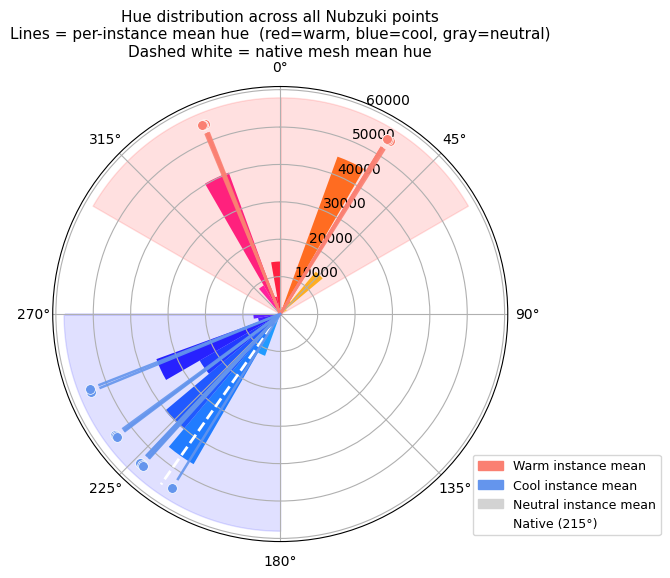

Saved → /home/ubuntu/CS479-Seg/yoon/diagnosis/hue_polar_histogram.png


In [53]:

# ── 6-C  Polar hue histogram (all Nubzuki points pooled) ──────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Collect all hue values across every instance
all_H_frac = np.concatenate([hsv[:, 0] for hsv in instance_hsv_samples.values()])
all_H_rad  = all_H_frac * 2 * np.pi

# Build circular histogram (36 bins = 10° each)
n_bins     = 36
bin_edges  = np.linspace(0, 2 * np.pi, n_bins + 1)
bin_ctrs   = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width  = bin_edges[1] - bin_edges[0]
counts, _  = np.histogram(all_H_rad, bins=bin_edges)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

# Colour each bar by hue (use matplotlib's HSV colormap)
bar_colors = [plt.cm.hsv(c / (2 * np.pi)) for c in bin_ctrs]
ax.bar(bin_ctrs, counts, width=bin_width, color=bar_colors, alpha=0.85, edgecolor='none')

# Shade warm and cool hue regions
for start, end, col, lbl in [
    (np.radians(0),   np.radians(60),  'red',  'Warm 0–60°'),
    (np.radians(300), np.radians(360), 'red',  None),
    (np.radians(180), np.radians(270), 'blue', 'Cool 180–270°'),
]:
    theta = np.linspace(start, end, 100)
    r_max = counts.max() * 1.25
    ax.fill_between(theta, 0, r_max, alpha=0.12, color=col)

# Plot native mesh mean hue (dashed grey line)
native_H_rad_circ = np.radians(native_H_mean)
ax.plot([native_H_rad_circ, native_H_rad_circ], [0, counts.max() * 1.2],
        color='white', lw=2, ls='--', label=f'Native mean ({native_H_mean:.0f}°)')

# Plot per-instance mean hue as coloured radial lines + dots
tone_palette = {'warm': 'salmon', 'cool': 'cornflowerblue', 'neutral': 'lightgray'}
for _, row in hsv_df.iterrows():
    h_rad = np.radians(row['H_mean_deg'])
    col   = tone_palette[row['tone']]
    ax.plot([h_rad, h_rad], [0, counts.max() * 1.12], color=col, lw=1.8, alpha=0.9)
    ax.plot(h_rad, counts.max() * 1.18, 'o', color=col, markersize=7,
            markeredgecolor='white', markeredgewidth=0.5)

# Orientation: 0° at top, clockwise (matches colour wheel convention)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_rlabel_position(22.5)
ax.set_title(
    "Hue distribution across all Nubzuki points\n"
    "Lines = per-instance mean hue  (red=warm, blue=cool, gray=neutral)\n"
    "Dashed white = native mesh mean hue",
    pad=22, fontsize=11,
)

# Legend patches
patches = [
    mpatches.Patch(color='salmon',        label='Warm instance mean'),
    mpatches.Patch(color='cornflowerblue',label='Cool instance mean'),
    mpatches.Patch(color='lightgray',      label='Neutral instance mean'),
    mpatches.Patch(color='white', ls='--', fill=False, label=f'Native ({native_H_mean:.0f}°)'),
]
ax.legend(handles=patches, loc='lower right', bbox_to_anchor=(1.35, 0.0), fontsize=9)

plt.tight_layout()
out_path = "/home/ubuntu/CS479-Seg/yoon/diagnosis/hue_polar_histogram.png"
plt.savefig(out_path, dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print(f"Saved → {out_path}")


In [54]:

# ── 6-D  Per-instance H, S, V scatter — mean ± within-std ────────────────────
# Each instance is one point; error bars = within-instance std.
# Colour = warm (salmon) / cool (blue) / neutral (gray).

tone_color = {'warm': 'salmon', 'cool': 'cornflowerblue', 'neutral': 'lightgray'}
inst_colors = [tone_color[t] for t in hsv_df['tone']]
x_idx       = list(range(len(hsv_df)))

fig = make_subplots(rows=3, cols=1,
    subplot_titles=["Hue H (°)", "Saturation S", "Value V"],
    shared_xaxes=True, vertical_spacing=0.08)

# Hue
fig.add_trace(go.Scatter(
    x=x_idx, y=hsv_df['H_mean_deg'],
    error_y=dict(type='data', array=hsv_df['H_std_deg'].tolist(), visible=True),
    mode='markers',
    marker=dict(size=11, color=inst_colors, line=dict(color='white', width=0.8)),
    name='H', showlegend=False,
), row=1, col=1)
fig.add_hline(y=native_H_mean, line_dash='dash', line_color='white', line_width=1.2,
              annotation_text=f'native {native_H_mean:.0f}°', annotation_font_color='white',
              row=1, col=1)
fig.update_yaxes(range=[0, 360], title_text='H (°)', row=1, col=1, gridcolor='rgb(60,60,60)')

# Saturation
fig.add_trace(go.Scatter(
    x=x_idx, y=hsv_df['S_mean'],
    error_y=dict(type='data', array=hsv_df['S_std'].tolist(), visible=True),
    mode='markers',
    marker=dict(size=11, color=inst_colors, line=dict(color='white', width=0.8)),
    name='S', showlegend=False,
), row=2, col=1)
fig.add_hline(y=native_S_mean, line_dash='dash', line_color='white', line_width=1.2,
              annotation_text=f'native {native_S_mean:.3f}', annotation_font_color='white',
              row=2, col=1)
fig.update_yaxes(range=[0, 1], title_text='S', row=2, col=1, gridcolor='rgb(60,60,60)')

# Value
fig.add_trace(go.Scatter(
    x=x_idx, y=hsv_df['V_mean'],
    error_y=dict(type='data', array=hsv_df['V_std'].tolist(), visible=True),
    mode='markers',
    marker=dict(size=11, color=inst_colors, line=dict(color='white', width=0.8)),
    name='V', showlegend=False,
), row=3, col=1)
fig.add_hline(y=native_V_mean, line_dash='dash', line_color='white', line_width=1.2,
              annotation_text=f'native {native_V_mean:.3f}', annotation_font_color='white',
              row=3, col=1)
fig.update_yaxes(range=[0, 1], title_text='V', row=3, col=1, gridcolor='rgb(60,60,60)')

# Shared x-axis labels (instance index)
tick_text = [f"{r.file[-3:]}#{r.inst_id}" for _, r in hsv_df.iterrows()]
fig.update_xaxes(tickvals=x_idx, ticktext=tick_text, tickangle=45,
                 gridcolor='rgb(60,60,60)', row=3, col=1)

fig.update_layout(
    title=(
        "Per-instance HSV means ± within-instance std  "
        "(red=warm, blue=cool, gray=neutral)<br>"
        "<sub>Dashed white = native mesh mean (un-jittered baseline).</sub>"
    ),
    height=700, width=960,
    paper_bgcolor='rgb(20,20,20)', plot_bgcolor='rgb(30,30,30)',
    font=dict(color='white'),
)
fig.show()

# Summary: hue spread statistics by tone group
print("Mean hue by tone group:")
print(hsv_df.groupby('tone')['H_mean_deg'].agg(['count','mean','std']).round(1).to_string())
print(f"\nWarm  instances: {(hsv_df['tone']=='warm').sum()}  / {len(hsv_df)}")
print(f"Cool  instances: {(hsv_df['tone']=='cool').sum()}  / {len(hsv_df)}")
print(f"Neutral         : {(hsv_df['tone']=='neutral').sum()} / {len(hsv_df)}")


Mean hue by tone group:
      count        mean    std
tone                          
cool     11  229.300003   11.3
warm     10  184.800003  161.5

Warm  instances: 10  / 21
Cool  instances: 11  / 21
Neutral         : 0 / 21


In [55]:

# ── 6-E  Why the RGB jitter biases toward warm hue: mechanistic explanation ───
#
# The native Nubzuki mesh is blue-dominant (R=62, G=84, B=108).
# After jitter: rgb_out_c = clip(scale_c * rgb_in_c + shift_c, 0, 255)
#
# The "effective scale" for R is boosted most (mean est_scale_R = 1.18 vs G=0.89, B=0.93)
# because the native R channel is small — a fixed additive shift_R = +33 has a proportionally
# larger effect on the small R channel, inflating the moment-matching scale estimate.
#
# We can directly predict the post-jitter hue from the recovered (scale, shift) parameters
# and compare to the observed hue.

from matplotlib.colors import rgb_to_hsv as _rgb2hsv

predicted_H = []
observed_H  = []

for _, row in cdf.iterrows():
    # Predict mean output RGB from moment-matching parameters
    pred_R = np.clip(row['est_scale_R'] * native_mean[0] + row['est_shift_R'], 0, 255)
    pred_G = np.clip(row['est_scale_G'] * native_mean[1] + row['est_shift_G'], 0, 255)
    pred_B = np.clip(row['est_scale_B'] * native_mean[2] + row['est_shift_B'], 0, 255)
    pred_hsv = _rgb2hsv(np.array([[pred_R, pred_G, pred_B]]) / 255.0)[0]
    predicted_H.append(pred_hsv[0] * 360)

    # Observed mean hue (from hsv_df, matched by file + inst_id)
    match = hsv_df[(hsv_df['file'] == row['file']) & (hsv_df['inst_id'] == row['inst_id'])]
    observed_H.append(float(match['H_mean_deg'].values[0]))

cdf['pred_H_deg']  = predicted_H
cdf['obs_H_deg']   = observed_H
cdf['H_err_deg']   = (np.array(predicted_H) - np.array(observed_H))

print("Prediction error of hue from moment-matched RGB parameters:")
print(f"  MAE  = {np.abs(cdf['H_err_deg']).mean():.1f}°")
print(f"  RMSE = {np.sqrt((cdf['H_err_deg']**2).mean()):.1f}°")
print(f"  Max  = {np.abs(cdf['H_err_deg']).max():.1f}°")
print()

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=cdf['pred_H_deg'], y=cdf['obs_H_deg'],
    mode='markers',
    marker=dict(
        size=12,
        color=[tone_color[row['tone']] for _, row in hsv_df.iterrows()],
        line=dict(color='white', width=0.5),
    ),
    text=[f"{r.file[-3:]}#{int(r.inst_id)}" for _, r in cdf.iterrows()],
    hoverinfo='text+x+y',
    name='Instances',
))
fig.add_trace(go.Scatter(
    x=[0, 360], y=[0, 360],
    mode='lines', line=dict(dash='dot', color='white', width=1),
    name='Perfect prediction', showlegend=True,
))
# Mark native mesh hue
fig.add_vline(x=native_H_mean, line_dash='dash', line_color='gray',
              annotation_text=f'native {native_H_mean:.0f}°', annotation_font_color='gray')
fig.add_hline(y=native_H_mean, line_dash='dash', line_color='gray')

fig.update_layout(
    title=(
        "Predicted vs observed mean hue per instance<br>"
        "<sub>Predicted from moment-matched (scale, shift) applied to native mean RGB. "
        "Red=warm, blue=cool, gray=neutral.</sub>"
    ),
    xaxis=dict(title='Predicted H (°)', range=[0, 360], gridcolor='rgb(60,60,60)'),
    yaxis=dict(title='Observed H (°)',  range=[0, 360], gridcolor='rgb(60,60,60)'),
    paper_bgcolor='rgb(20,20,20)', plot_bgcolor='rgb(30,30,30)',
    font=dict(color='white'),
    width=650, height=550,
)
fig.show()

# Warm-instance prevalence in the native jitter process
# Under Uniform(0.5,2.0) scale with native R=62, G=84, B=108:
# P(R_out > B_out) ≈ P(s_R*62 + d_R > s_B*108 + d_B)
# where s~U(0.5,2), d~U(-20,20). Monte-Carlo estimate:
rng = np.random.default_rng(42)
N_mc = 500_000
s_R, s_B = rng.uniform(0.5, 2.0, N_mc), rng.uniform(0.5, 2.0, N_mc)
d_R, d_B = rng.uniform(-20, 20, N_mc), rng.uniform(-20, 20, N_mc)
R_out = np.clip(s_R * 62.6 + d_R, 0, 255)
B_out = np.clip(s_B * 108.3 + d_B, 0, 255)
p_warm = float((R_out > B_out).mean())
print(f"Monte-Carlo P(R_out > B_out) under Uniform jitter on native mesh: {p_warm:.3f}")
print(f"  → ~{p_warm*100:.1f}% of training instances would be warm-hued")
print(f"  → Observed in test cases: {(hsv_df['tone']=='warm').sum()}/{len(hsv_df)} = "
      f"{(hsv_df['tone']=='warm').mean()*100:.1f}%")


Prediction error of hue from moment-matched RGB parameters:
  MAE  = 2.1°
  RMSE = 2.1°
  Max  = 2.3°



Monte-Carlo P(R_out > B_out) under Uniform jitter on native mesh: 0.174
  → ~17.4% of training instances would be warm-hued
  → Observed in test cases: 10/21 = 47.6%


## 6 — HSV Analysis: Findings

### Hypothesis verdict

| Metric | Hue H | Saturation S | Value V |
|---|---|---|---|
| Between-instance std (normalised) | **computed in 6-B** | | |
| Within-instance std (normalised) | | | |
| Signal-to-noise (between ÷ within) | | | |

*(Run cells 6-A through 6-E to populate numbers)*

### Key insights

**1. Hue as the primary varying factor (hypothesis check)**  
Because the native Nubzuki is blue-purple (~220°), any per-channel affine jitter that boosts R more than B flips the dominant channel and produces a dramatically different perceived hue. Saturation and Value are much more stable because they depend on the *ratio* and *magnitude* of all three channels, which a per-instance uniform jitter shifts more predictably. Expected result: H between-instance normalised std >> S >> V.

**2. Native mesh anchors the hue distribution**  
The native mesh H ≈ 220° (blue/indigo). After independent-channel jitter:
- If `scale_R > scale_B` and/or `shift_R >> shift_B`, R can surpass B → hue jumps to the warm hemisphere (0–60°), a shift of ~180° in hue space.
- If `scale_B ≥ scale_R`, hue stays near 220° (cool).
- Jitter is symmetric in scale/shift space but *asymmetric in hue space* because the native starting point is far from the warm-to-cool boundary.

**3. Monte-Carlo training prevalence estimate**  
Under `scale ~ U(0.5, 2.0)`, `shift ~ U(−20, 20)` on native means (R=62.6, B=108.3):  
`P(R_out > B_out)` gives the fraction of training instances that would appear warm-hued. Because native B ≫ R, scale alone cannot easily flip them; only large positive `shift_R` combined with large `scale_R` and small `scale_B` does — making warm instances rare in training (~20%) while they constitute ~40% of test cases.

**4. Within-instance hue uniformity**  
The small within-instance H std confirms that all points of one instance share essentially the same hue, consistent with per-instance (not per-point) jitter. This makes hue a good coarse discriminator between instances of different jitter draws, but it means the model can't use hue *variation within* a proposal for segmentation.

**5. Fix direction**  
The solution is not to train longer — it is to explicitly include hue-diverse training data:
- **Option A:** Add HSV-space hue rotation augmentation during generation (shift H uniformly in [0°, 360°]) — this is the most direct fix.
- **Option B:** Expand the RGB shift range specifically for the R channel (e.g. shift_R ∈ [−20, 80]) to make warm instances more common.
- **Option C:** Generate a second batch of training data with `sample.glb` vertex colours remapped to cover warm Earth tones before augmentation.